<a href="https://colab.research.google.com/github/Docdoi/AI-Engineered_Nanoproteins_A_De_Novo_Approach_to_Inhibit_Hantavirus_Transmission-/blob/main/AlphaFold2onColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q "colabfold[alphafold]"

In [2]:
!nvidia-smi

Thu Aug 13 13:15:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   35C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
my_sequence = "NFDLHTTSMAQKSFTQVEWRKKSDTTGGGGGGGGGGGGGGGGGGGGGGGG/GGAGGGAGAGGVGVGGGGGGVPGGAG"

my_sequence = (
    my_sequence
    .replace("/", "")
    .replace(" ", "")
    .replace("\n", "")
    .upper()
)

valid_aa = set("ACDEFGHIKLMNPQRSTVWY")
invalid = set(my_sequence) - valid_aa

print("Length:", len(my_sequence))
print("Invalid characters:", invalid)

with open("my_sequence.fasta", "w") as f:
    f.write(">my_sequence\n")
    f.write(my_sequence + "\n")

print("my_sequence.fasta created")

Length: 76
Invalid characters: set()
my_sequence.fasta created


In [20]:
!colabfold_batch \
    my_sequence.fasta \
    results1 \
    --num-recycle 3 \
    --num-models 5

2026-08-13 13:27:41,576 Running colabfold 1.6.2

limited shared resource only capable of processing a few thousand MSAs per day. Please
submit jobs only from a single IP address. We reserve the right to limit access to the
server case-by-case when usage exceeds fair use. If you require more MSAs: You can 
precompute all MSAs with `colabfold_search` or host your own API and pass it to `--host-url`

2026-08-13 13:27:42,127 Running on GPU
2026-08-13 13:27:42,528 Found 5 citations for tools or databases
2026-08-13 13:27:42,528 Query 1/1: my_sequence (length 76)
2026-08-13 13:27:43,169 Sleeping for 5s. Reason: PENDING
2026-08-13 13:27:48,386 Sleeping for 5s. Reason: RUNNING
2026-08-13 13:27:53,593 Sleeping for 6s. Reason: RUNNING
COMPLETE: 100% 150/150 [00:17<00:00,  8.78it/s]
2026-08-13 13:28:00,655 Setting max_seq=68, max_extra_seq=1
2026-08-13 13:28:29,331 alphafold2_ptm_model_1_seed_000 recycle=0 pLDDT=56.9 pTM=0.147
2026-08-13 13:28:30,254 alphafold2_ptm_model_1_seed_000 recycle=1 pLDD

In [21]:
import glob

my_pdb_files = sorted(
    glob.glob("results1/**/*.pdb", recursive=True)
)

print("PDB files for MY sequence:", len(my_pdb_files))

for f in my_pdb_files:
    print(f)

PDB files for MY sequence: 5
results1/my_sequence_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.pdb
results1/my_sequence_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb
results1/my_sequence_unrelaxed_rank_003_alphafold2_ptm_model_4_seed_000.pdb
results1/my_sequence_unrelaxed_rank_004_alphafold2_ptm_model_5_seed_000.pdb
results1/my_sequence_unrelaxed_rank_005_alphafold2_ptm_model_3_seed_000.pdb


In [25]:
import glob
import os

pdb_files = sorted(glob.glob("results1/**/*.pdb", recursive=True))

for i, file in enumerate(pdb_files):
    print(i, os.path.basename(file))

0 my_sequence_unrelaxed_rank_001_alphafold2_ptm_model_1_seed_000.pdb
1 my_sequence_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb
2 my_sequence_unrelaxed_rank_003_alphafold2_ptm_model_4_seed_000.pdb
3 my_sequence_unrelaxed_rank_004_alphafold2_ptm_model_5_seed_000.pdb
4 my_sequence_unrelaxed_rank_005_alphafold2_ptm_model_3_seed_000.pdb


In [29]:
selected_index = 1

selected_pdb = pdb_files[selected_index]

print("Selected PDB:")
print(selected_pdb)

Selected PDB:
results1/my_sequence_unrelaxed_rank_002_alphafold2_ptm_model_2_seed_000.pdb


In [30]:
import pandas as pd

residue_scores = {}

with open(selected_pdb, "r") as f:
    for line in f:
        if line.startswith("ATOM"):
            chain = line[21].strip()
            resnum = int(line[22:26])
            resname = line[17:20].strip()
            plddt = float(line[60:66])

            key = (chain, resnum, resname)

            if key not in residue_scores:
                residue_scores[key] = []

            residue_scores[key].append(plddt)

rows = []

for (chain, resnum, resname), scores in residue_scores.items():
    rows.append({
        "Chain": chain,
        "Residue": resnum,
        "AA": resname,
        "pLDDT": sum(scores) / len(scores)
    })

df = pd.DataFrame(rows)

print(df)

print("\nMean pLDDT:", round(df["pLDDT"].mean(), 2))

   Chain  Residue   AA  pLDDT
0      A        1  ASN  53.47
1      A        2  PHE  69.12
2      A        3  ASP  75.38
3      A        4  LEU  72.50
4      A        5  HIS  69.69
..   ...      ...  ...    ...
71     A       72  PRO  58.31
72     A       73  GLY  44.31
73     A       74  GLY  44.97
74     A       75  ALA  42.03
75     A       76  GLY  40.34

[76 rows x 4 columns]

Mean pLDDT: 56.05


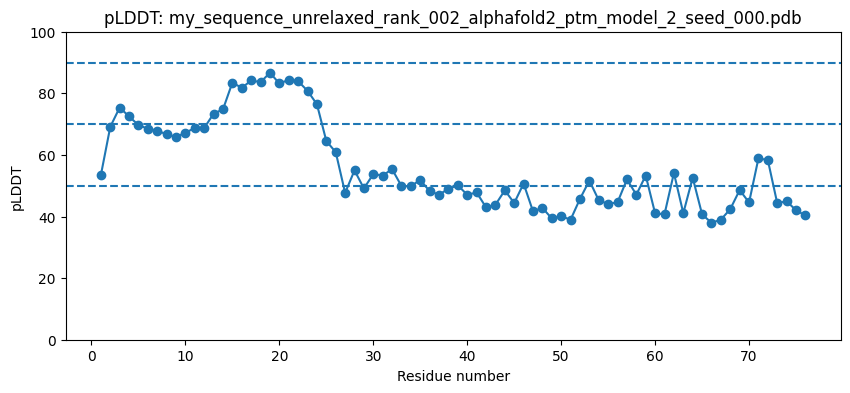

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.plot(
    df["Residue"],
    df["pLDDT"],
    marker="o"
)

plt.axhline(90, linestyle="--")
plt.axhline(70, linestyle="--")
plt.axhline(50, linestyle="--")

plt.xlabel("Residue number")
plt.ylabel("pLDDT")
plt.title(f"pLDDT: {os.path.basename(selected_pdb)}")
plt.ylim(0, 100)

plt.show()

In [32]:
import glob
import os
import pandas as pd

pdb_files = sorted(glob.glob("results1/**/*.pdb", recursive=True))

summary = []

for pdb_file in pdb_files:

    plddt_values = []

    with open(pdb_file, "r") as f:
        for line in f:
            if line.startswith("ATOM"):
                plddt_values.append(float(line[60:66]))

    mean_plddt = sum(plddt_values) / len(plddt_values)

    summary.append({
        "Model": os.path.basename(pdb_file),
        "Mean pLDDT": mean_plddt
    })

summary_df = pd.DataFrame(summary)

summary_df = summary_df.sort_values(
    "Mean pLDDT",
    ascending=False
).reset_index(drop=True)

print(summary_df)

                                               Model  Mean pLDDT
0  my_sequence_unrelaxed_rank_001_alphafold2_ptm_...   62.855208
1  my_sequence_unrelaxed_rank_002_alphafold2_ptm_...   60.910370
2  my_sequence_unrelaxed_rank_003_alphafold2_ptm_...   57.941227
3  my_sequence_unrelaxed_rank_004_alphafold2_ptm_...   54.573565
4  my_sequence_unrelaxed_rank_005_alphafold2_ptm_...   51.299931
